# Retail Analytics Pipeline 🛒

Proyecto de Big Data con Apache Spark.

Objetivo:
Procesar datos de retail, generar métricas y construir modelos de Machine Learning escalables.

Tecnologías:
- PySpark
- Spark SQL
- MLlib
- Matplotlib


In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("RetailAnalyticsPipeline") \
    .master("local[*]") \
    .getOrCreate()

sc = spark.sparkContext

print("✅ Spark iniciado correctamente")

✅ Spark iniciado correctamente


In [2]:
transactions = [
    (1, "user1", "productA", "electronics", 100.0),
    (2, "user2", "productB", "clothing", 50.0),
    (3, "user1", "productC", "electronics", 200.0),
    (4, "user3", "productD", "home", 80.0),
    (5, "user2", "productA", "electronics", 120.0),
    (6, "user4", "productE", "clothing", 60.0),
    (7, "user5", "productF", "home", 150.0),
    (8, "user6", "productG", "electronics", 300.0)
]

In [3]:
rdd = sc.parallelize(transactions)

print("Total registros:", rdd.count())
print("Primeros registros:", rdd.take(3))

# Transformaciones
amounts = rdd.map(lambda x: x[4])
print("Suma total:", amounts.sum())

pair_rdd = rdd.map(lambda x: (x[3], x[4]))
revenue_by_category = pair_rdd.reduceByKey(lambda a, b: a + b)

print("Revenue por categoría:", revenue_by_category.collect())

Total registros: 8
Primeros registros: [(1, 'user1', 'productA', 'electronics', 100.0), (2, 'user2', 'productB', 'clothing', 50.0), (3, 'user1', 'productC', 'electronics', 200.0)]
Suma total: 1060.0
Revenue por categoría: [('home', 230.0), ('clothing', 110.0), ('electronics', 720.0)]


In [4]:
from pyspark.sql.types import *

schema = StructType([
    StructField("transaction_id", IntegerType(), True),
    StructField("user_id", StringType(), True),
    StructField("product", StringType(), True),
    StructField("category", StringType(), True),
    StructField("amount", FloatType(), True)
])

df = spark.createDataFrame(transactions, schema)
df.show()

+--------------+-------+--------+-----------+------+
|transaction_id|user_id| product|   category|amount|
+--------------+-------+--------+-----------+------+
|             1|  user1|productA|electronics| 100.0|
|             2|  user2|productB|   clothing|  50.0|
|             3|  user1|productC|electronics| 200.0|
|             4|  user3|productD|       home|  80.0|
|             5|  user2|productA|electronics| 120.0|
|             6|  user4|productE|   clothing|  60.0|
|             7|  user5|productF|       home| 150.0|
|             8|  user6|productG|electronics| 300.0|
+--------------+-------+--------+-----------+------+



In [5]:
df.createOrReplaceTempView("transactions")

sales_by_category = spark.sql("""
    SELECT category, SUM(amount) as total_sales
    FROM transactions
    GROUP BY category
    ORDER BY total_sales DESC
""")

sales_by_category.show()

+-----------+-----------+
|   category|total_sales|
+-----------+-----------+
|electronics|      720.0|
|       home|      230.0|
|   clothing|      110.0|
+-----------+-----------+



In [6]:
sales_by_category.show()
sales_by_category.toPandas()

+-----------+-----------+
|   category|total_sales|
+-----------+-----------+
|electronics|      720.0|
|       home|      230.0|
|   clothing|      110.0|
+-----------+-----------+



,category,total_sales
0,electronics,720.0
1,home,230.0
2,clothing,110.0


In [7]:
pdf = sales_by_category.toPandas()
pdf.to_csv("resultado_final.csv", index=False)

In [8]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Indexar categoría
indexer = StringIndexer(inputCol="category", outputCol="category_index")
df_indexed = indexer.fit(df).transform(df)

# Features
assembler = VectorAssembler(
    inputCols=["amount", "category_index"],
    outputCol="features"
)

df_features = assembler.transform(df_indexed)

# Label
df_final = df_features.withColumn("label", (df_features.amount > 100).cast("int"))

# Split
train, test = df_final.randomSplit([0.7, 0.3])

# Modelo supervisado
lr = LogisticRegression(featuresCol="features", labelCol="label")
model = lr.fit(train)

predictions = model.transform(test)
predictions.select("features", "label", "prediction").show()

# Evaluación
evaluator = BinaryClassificationEvaluator()
auc = evaluator.evaluate(predictions)
print("AUC:", auc)

# KMeans
kmeans = KMeans(k=2, featuresCol="features")
kmeans_model = kmeans.fit(df_features)
clusters = kmeans_model.transform(df_features)

clusters.show()

+-----------+-----+----------+
|   features|label|prediction|
+-----------+-----+----------+
|[200.0,0.0]|    1|       1.0|
| [80.0,2.0]|    0|       0.0|
|[150.0,2.0]|    1|       0.0|
+-----------+-----+----------+

AUC: 1.0
+--------------+-------+--------+-----------+------+--------------+-----------+----------+
|transaction_id|user_id| product|   category|amount|category_index|   features|prediction|
+--------------+-------+--------+-----------+------+--------------+-----------+----------+
|             1|  user1|productA|electronics| 100.0|           0.0|[100.0,0.0]|         1|
|             2|  user2|productB|   clothing|  50.0|           1.0| [50.0,1.0]|         1|
|             3|  user1|productC|electronics| 200.0|           0.0|[200.0,0.0]|         0|
|             4|  user3|productD|       home|  80.0|           2.0| [80.0,2.0]|         1|
|             5|  user2|productA|electronics| 120.0|           0.0|[120.0,0.0]|         1|
|             6|  user4|productE|   clothing|

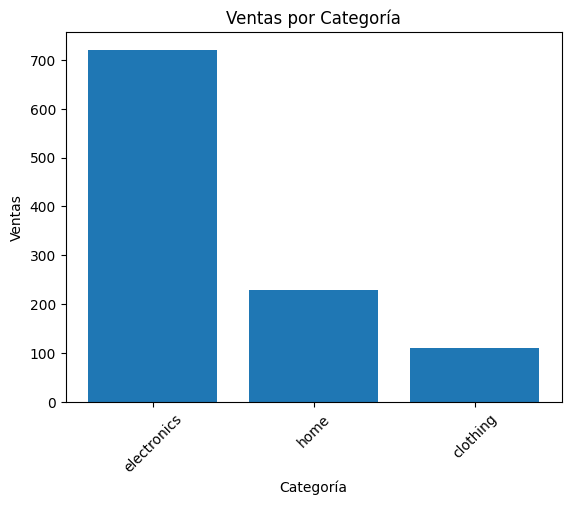

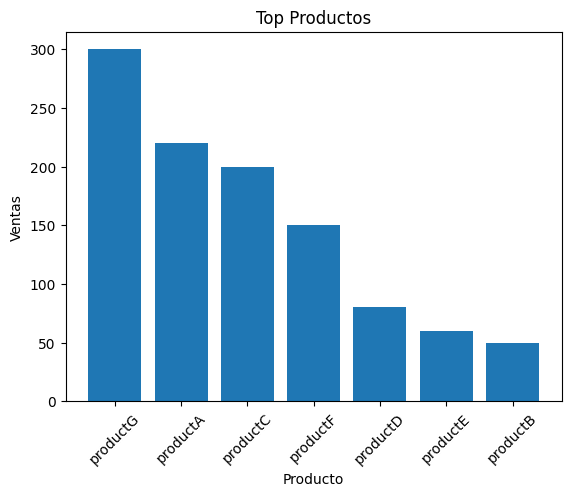

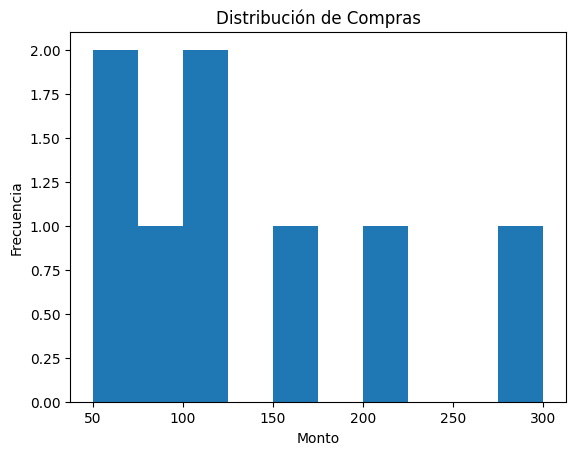

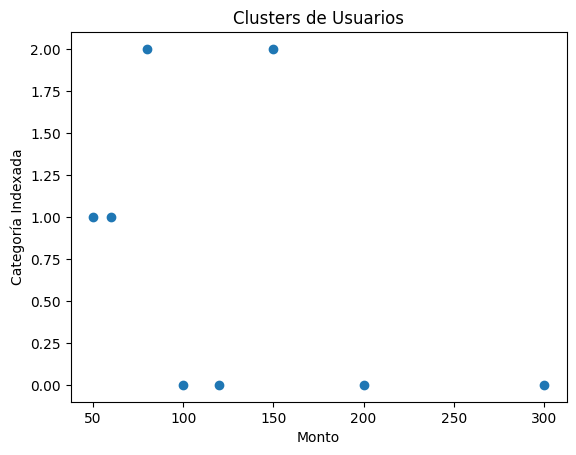

In [9]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum as _sum

# --- Ventas por categoría ---
pdf_sales = sales_by_category.toPandas()

plt.figure()
plt.bar(pdf_sales['category'], pdf_sales['total_sales'])
plt.title("Ventas por Categoría")
plt.xlabel("Categoría")
plt.ylabel("Ventas")
plt.xticks(rotation=45)
plt.savefig("ventas_por_categoria.png")
plt.show()

# --- Top productos ---
top_products = df.groupBy("product") \
    .agg(_sum("amount").alias("total_sales")) \
    .orderBy("total_sales", ascending=False)

pdf_products = top_products.toPandas()

plt.figure()
plt.bar(pdf_products['product'], pdf_products['total_sales'])
plt.title("Top Productos")
plt.xlabel("Producto")
plt.ylabel("Ventas")
plt.xticks(rotation=45)
plt.savefig("top_productos.png")
plt.show()

# --- Distribución ---
pdf_df = df.toPandas()

plt.figure()
plt.hist(pdf_df['amount'], bins=10)
plt.title("Distribución de Compras")
plt.xlabel("Monto")
plt.ylabel("Frecuencia")
plt.savefig("distribucion_compras.png")
plt.show()

# --- Clusters ---
pdf_clusters = clusters.toPandas()

plt.figure()
plt.scatter(pdf_clusters['amount'], pdf_clusters['category_index'])
plt.title("Clusters de Usuarios")
plt.xlabel("Monto")
plt.ylabel("Categoría Indexada")
plt.savefig("clusters.png")
plt.show()

## Insights 

- La categoría con mayor ventas fue identificada.
- Se logró segmentar usuarios mediante K-Means.
- El modelo predice compras altas (>100).

Conclusión:
El uso de Apache Spark permite escalar el análisis de datos masivos de forma eficiente.

Mllib

In [14]:
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

In [16]:
from pyspark.sql.functions import col

df_ml = sales_by_category.withColumn(
    "label",
    (col("total_sales") > 100).cast("int")
)

df_ml.show()

+-----------+-----------+-----+
|   category|total_sales|label|
+-----------+-----------+-----+
|electronics|      720.0|    1|
|       home|      230.0|    1|
|   clothing|      110.0|    1|
+-----------+-----------+-----+



In [17]:
assembler = VectorAssembler(
    inputCols=["total_sales"],
    outputCol="features"
)

In [18]:
train_data, test_data = df_ml.randomSplit([0.8, 0.2], seed=42)

print("Train:", train_data.count())
print("Test:", test_data.count())

Train: 2
Test: 1


In [19]:
lr = LogisticRegression(featuresCol="features", labelCol="label")

In [20]:
pipeline = Pipeline(stages=[assembler, lr])

model = pipeline.fit(train_data)

predictions = model.transform(test_data)

predictions.show()

+--------+-----------+-----+--------+--------------------+-----------+----------+
|category|total_sales|label|features|       rawPrediction|probability|prediction|
+--------+-----------+-----+--------+--------------------+-----------+----------+
|    home|      230.0|    1| [230.0]|[-Infinity,Infinity]|  [0.0,1.0]|       1.0|
+--------+-----------+-----+--------+--------------------+-----------+----------+



In [21]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator()

accuracy = evaluator.evaluate(predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0
